<img src="logo_UNSAM.jpg" align="right" width="120" /> 
<br><br><br><br>
<div style="text-align: center;">

### Analisis y procesamiento de señales 1C 2026
# Trabajo Práctico Nº2

### Melanie amicucci

<br>
</div>

# Introducción
En este trabajo se estudió el comportamiento de un conversor analógico-digital (ADC) al procesar una señal senoidal contaminada con ruido.
El objetivo principal es analizar los efectos de la cuantización y del ruido sobre la señal, tanto en el dominio del tiempo como en el dominio de la frecuencia.
El análisis se realiza en base al dominio del tiempo, donde se comparan la señal original, la señal contaminada con ruido y la señal cuantizada, permitiendo visualizar las deformaciones introducidas por el sistema. En el dominio de la frecuencia, se utiliza la Transformada Discreta de Fourier (DFT) para estudiar la distribución espectral de la potencia, identificando el componente de la señal y los distintos pisos de ruido (analógico y digital). Finalmente, se analiza la distribución del error de cuantización mediante un histograma, verificando su comportamiento uniforme dentro del intervalo teórico 


# Generar una señal senoidal base 
Se definió una función para generar una señal senoidal discreta en el tiempo, representa la señal analógica ideal que será utilizada como base para el análisis posterior.
La señal se construye a partir de sus parámetros fundamentales: amplitud máxima, frecuencia, fase y offset. Además, se define el vector de tiempo en función de la frecuencia de muestreo y la cantidad de muestras lo que permite representar la señal en forma discreta.
$$
x(t) = A \cdot \sin(2\pi F t + \phi) + DC
$$

donde 
- A es la amplitud de la señal que define el valor máximo
- F es la frecuencia en Hz que indica la cantidad de ciclos por segundo
- t es el tiempo
- $\phi$ : ph en nuestro codigo, es la fase inicial de la señal
- DC: valor medio, el desplazamiento vertical

In [27]:
import numpy as np  #importar la libreria numpy
def mi_funcion_sen(vmax, dc,ff,ph,nn,fs): #defino la funcion senoidal
   
        ts=1/fs #frecuencia de muestreo
   
        x = np.arange(nn) #-1 rellena automaticamente la cantidad de filas
        
        tt=x*ts #tt=[0,1*ts,2*ts,...,(n-1)*ts] #defino el tiempo continuo como un vector 

        xx=vmax * np.sin (2 * np.pi * ff * tt+ ph) + dc
        
        return tt,xx

### Definición de parametros de la señal 
Se definen los parámetros de la señal senoidal, incluyendo amplitud, frecuencia, fase, offset, cantidad de muestras y frecuencia de muestreo.
<br>
La amplitud se elige como $ \sqrt{2}$ para obtener una señal de potencia unitaria, mientras que la frecuencia se fija como $\frac{fs}{N}$ para garantizar periodicidad en el intervalo discreto.

In [28]:
vmax=np.sqrt(2) 
nn=1000 
fs=1000 
dc=0
ff= fs/nn
ph=0 

tt,xx = mi_funcion_sen(vmax, dc,ff,ph,nn,fs)

## Modelación de la señal con ruido 

Se establecieron las características del ADC. Se considera un conversor de 𝐵=4, lo que implica que la amplitud de la señal será representada mediante $2^B = 16$ niveles discretos. Ademas, se define un rango de entrada de -V_f= 2V y +V_f=2V, correspondiente a un rango total (Full Scale Range) de 4 Volts.
<br>
Se calculó el paso de cuantización 
$$ q = \frac{2 V_F}{2^B} $$
representa la separacion entre escalones consecutivos del conversor, este valor determina la resolucion del ADC.
<br>
Luego se calculó la potencia teoria del ruido de cuatización
$$ P_q = \frac{q^2}{12} $$
Y finalmente el pfactor de escala $k_n$ permite ajustar la relacion entre el ruido analogico y el ruido de cuantizacion. La potencia de ruido analogico quedó definida como
$$ P_n = k_n . P_q$$

In [29]:
tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

B = 4
VF = 2 
q = (2 * VF) / (2**B) 
Pq = (q**2) / 12 
kn = 1
Pn = kn * Pq


## Modelación del ruido analogico 
Se modeló el ruido analogico que afecta a la señal antes de ingresar al conversor con el fin de hacer una prueba real y no teorica.
<br>
Se generó un ruido aleatorio con distribución gaussiana, de media cero y varianza unitaria. Este se escaló multiplicandolo por $\sqrt{P_n} $ para que la potencia final coincida con el definido anteriormente.
<br> 
Finalmente se suma a la señal senoidal original obteniendo la señal de entrada al ADC
$$ s_R [n]=s[n]+n[n]$$


In [30]:
ruido_base = np.random.normal(0, 1, xx.shape) 
ruido = np.sqrt(Pn) * ruido_base #escalo el ruido para que tenga potencia pn

sr = xx + ruido

## Cuantización 
La señal con ruido se limitó al rangodel ADC mediante la función clip. Esto representa la saturación del conversor, ya que cualquier valor que supere el rango $\pm V_F =2$ es recortado. 
<br>
Luego se aproxima cada muestra al nivel discreto mas cercano dvidiendo la señal por el paso de cuantización, redondeando al entero mas cercano y luego reescalando lo obtenido. 
<br>
La señal deja de ser continua en amplitud y pasa a tomar valores discretos, separados entre sí por q.


In [31]:
sr_clip = np.clip(sr, -VF, VF)
sq = q * np.round(sr_clip / q)

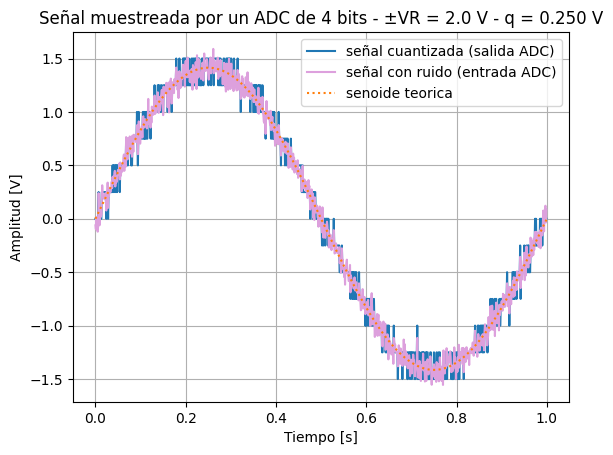

In [32]:
#%% GRAFICO EN EL TIEMPO
import matplotlib.pyplot as plt
plt.plot(tt, sq, label='señal cuantizada (salida ADC)')
plt.plot(tt, sr,color='plum', label='señal con ruido (entrada ADC)')
plt.plot(tt, xx, label='senoide teorica', linestyle=':')
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VR = {VF:.1f} V - q = {q:.3f} V')
plt.grid(True)
plt.legend()
plt.show()

# Analisis espectral de la señal cuantizada
En este bloque se observó la señal cuantizada en el dominio de la frecuencia mediante la Transformada Discreta de Fourier (DFT). El objetivo es observar cómo se distribuye la potencia de la señal y del ruido a lo largo del espectro.
<br>
Se aplicó la DFT a la señal cuantizada $s_Q[n]$ obteniendo su representación en frecuencia. Luego, se construye el eje de frecuencias a partir de la cantidad de muestras N de la frecuencia de muestreo $f_s$ lo que permite interpretar fisicamente cada componente espectral en Hertz.
<br>
La DFT presenta simetría conjugada, por lo que la parte correspondiente a frecuencias negativas resulta redundante. Por esta ello, se conserva únicamente el semiespectro de frecuencias positivas aplicado con una mascara.
<br>
Se calculó la densidad espectral de la señal cuantizada 
$$ s_Q= \frac{1}{N^2}|DFT[s_q(n)] |^2$$
<br>
La densidad espectral se expresó en decibeles
$$ S_Q,db=10. log_10 . (S_Q) $$
ya que el logaritmo de cero no está definido, los valores nulos se reemplazan por un valor muy pequeño, evitando errores numericos en el cálculo.
<br>
Finalmente, se calculan los niveles correspondientes al piso de ruido analógico y al piso de ruido digital, expresados también en dB. Estos valores se utilizan como referencias horizontales en el gráfico espectral, permitiendo comparar el efecto del ruido agregado con el del ruido de cuantización.

In [33]:
#%%FFT DE LA SEÑAL CUANTIZADA
DFT = np.fft.fft(sq) 
frecuencia = np.fft.fftfreq(nn, d=1/fs)

mask = frecuencia >= 0
frecuencia_pos = frecuencia[mask]
DFT_positivo = DFT [mask]

dens_pot_sq = (1 / nn**2) * (np.abs(DFT_positivo)**2)

dens_pot_sq[dens_pot_sq == 0] = 1e-20

dens_db_sq = 10 * np.log10(dens_pot_sq)

piso_analog_db = 10 * np.log10(Pn)
piso_digital_db = 10 * np.log10(Pq)


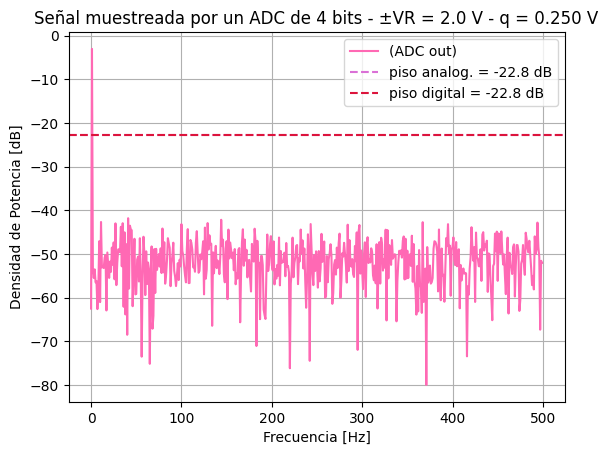

In [34]:
import matplotlib.pyplot as plt
plt.plot(frecuencia_pos, dens_db_sq,color='hotpink', label='(ADC out)')
#plt.axhline dibuja una linea horizontal en {pisoanalogico}, es un valor constante
plt.axhline(piso_analog_db, color='orchid', linestyle='--',
            label=f'piso analog. = {piso_analog_db:.1f} dB')
plt.axhline(piso_digital_db, color='crimson', linestyle='--',
            label=f'piso digital = {piso_digital_db:.1f} dB')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits - ±VR = {VF:.1f} V - q = {q:.3f} V')
plt.grid(True)
plt.legend()
plt.show()

Gráfico correspondiente a la densidad espectral

# Error de cuantización
Al cuantizar se genera un error debido a que el valor cuantiz ado no coincide exactamente con el valor real de la señal de entrada.
El error de cuantización se define como 
$$ e_q= s_Q - s_R$$
<br>
Este error esta acotado dentro de un intervalo determinado por el paso de cuantizacion q 
$$ -\frac {q}{2} \leq e_q \leq \frac {q} {2} $$
Esto se debe a que el cuantizador aproxima cada muestra al nivel más cercano, por lo que la diferencia máxima posible es de medio escalón.


In [35]:
error_q = sq - sr_clip

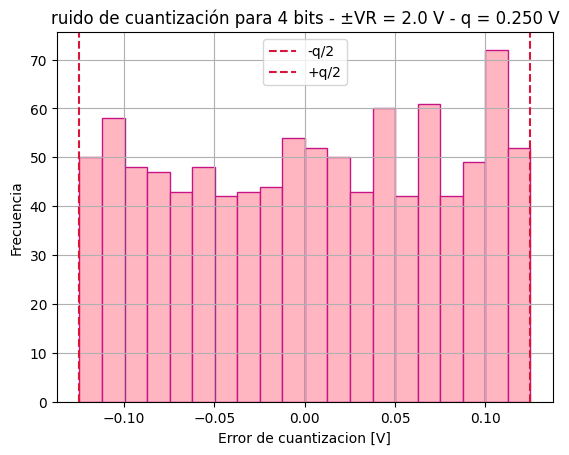

In [36]:
plt.hist(error_q, bins=20, edgecolor='mediumvioletred', color='lightpink') #bins divide el rango en 20
plt.axvline(-q/2, color='crimson', linestyle='--', label='-q/2') #axvline dibuja los limites teoricos del error
plt.axvline(q/2, color='crimson', linestyle='--', label='+q/2')
plt.xlabel('Error de cuantizacion [V]')
plt.ylabel('Frecuencia')
plt.title(f'ruido de cuantización para {B} bits - ±VR = {VF:.1f} V - q = {q:.3f} V')
plt.grid(True)
plt.legend()
plt.show()

### Histograma del error
Para analizar la distribución del error, se construye un histograma a partir de los valores obtenidos. Este gráfico permite observar la frecuencia de aparición de cada valor de error.
<br>
De acuerdo con los valores teóricos, el error de cuantización se comporta como una variable aleatoria con distribución uniforme dentro del intervalo $-\frac {q}{2} \leq e_q \leq \frac {q} {2} $. Por lo tanto, se espera que el histograma presente una forma aproximadamente rectangular, indicando que todos los valores dentro del rango tienen igual probabilidad.
<br>
Además, se representan mediante líneas verticales los límites teóricos del error, lo que permite verificar que los valores obtenidos se encuentran efectivamente dentro del intervalo esperado.

## Conclusión
En este trabajo se analizó el comportamiento de un ADC al procesar una señal senoidal con ruido. Se observó que el proceso de cuantización introduce un error debido a la discretización en amplitud, el cual depende del paso de cuantización y, por lo tanto, de la cantidad de bits del conversor.
<br>
Finalmente, el análisis del error mostró que este se encuentra acotado en el intervalo y presenta una distribución aproximadamente uniforme, coincidiendo con el modelo teórico.

# Analisis del ADC a diferentes configuraciones
En este apartado se configuró el codigo modificando la cantidad de bits que determinan el nivel de cuantizacion y el factor $k_n$ que regula la potencia del ruido analogico en relacion al ruido de cuantización.
<br>
### Al aumentar B
Se disminiye el paso de cuantizacion q, se reduce el error de cuantizacion y la señal cuantizada se aproxima mejor a la señal original.
<br> 
En el dominio del tiempo la señal es mas suave.
<br>
El error se reduce significativamente
### Al aumentar kn
Este parametro controla la potencia del ruido por lo que al aumentar k, aumenta el ruido y domina el ruido analogico 
En el dominio del tiempo, la señal se ve mas ruidosa

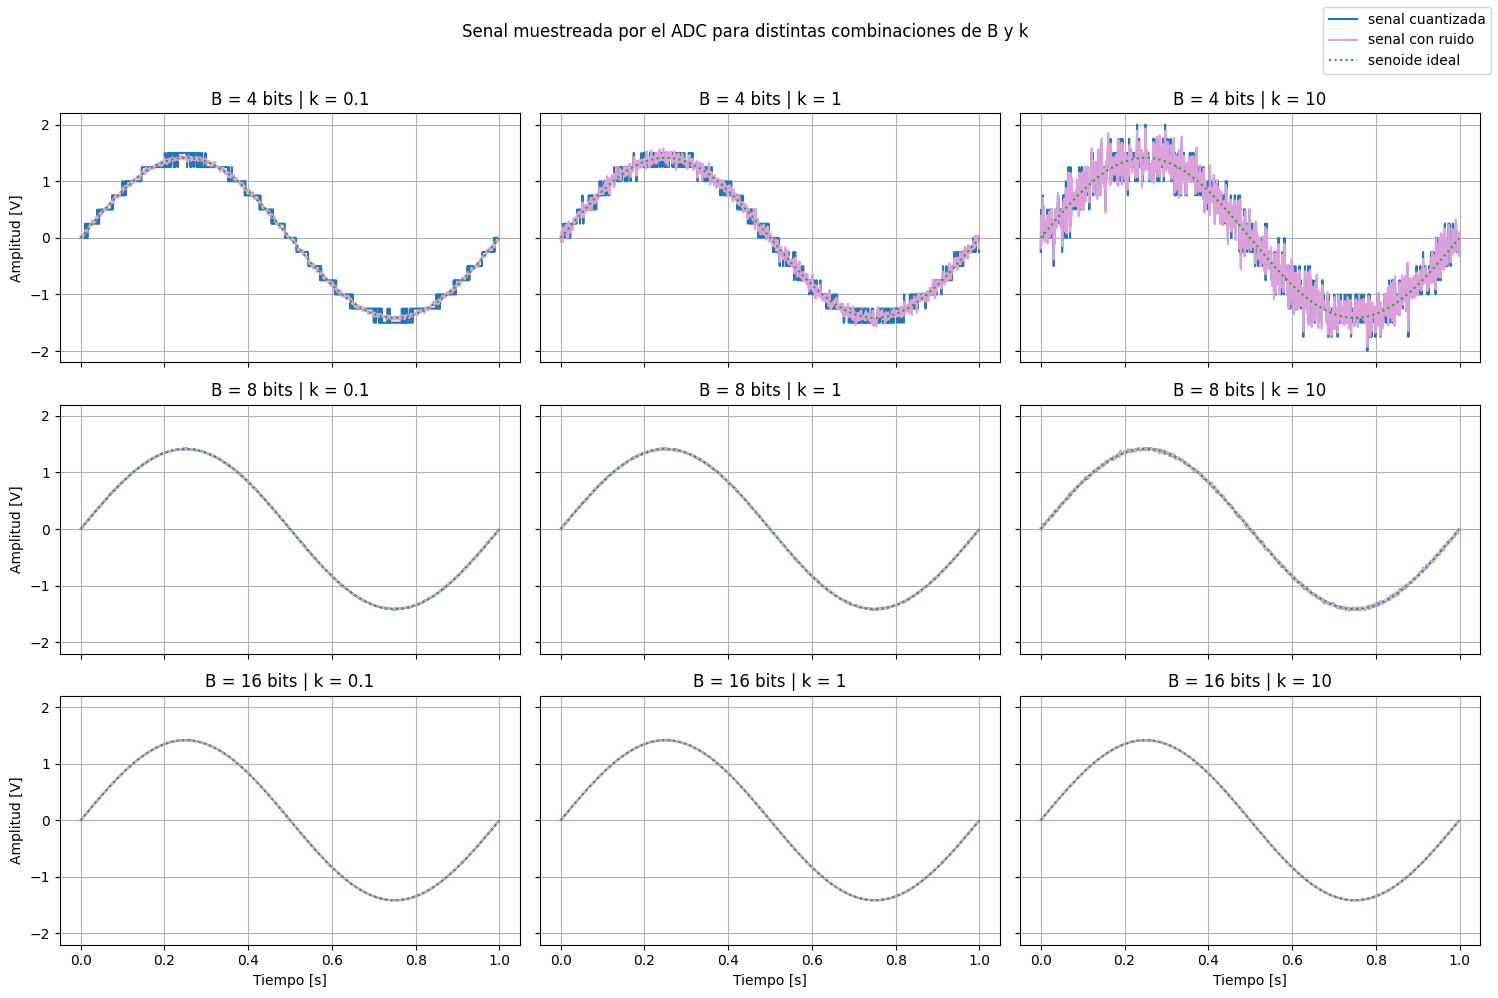

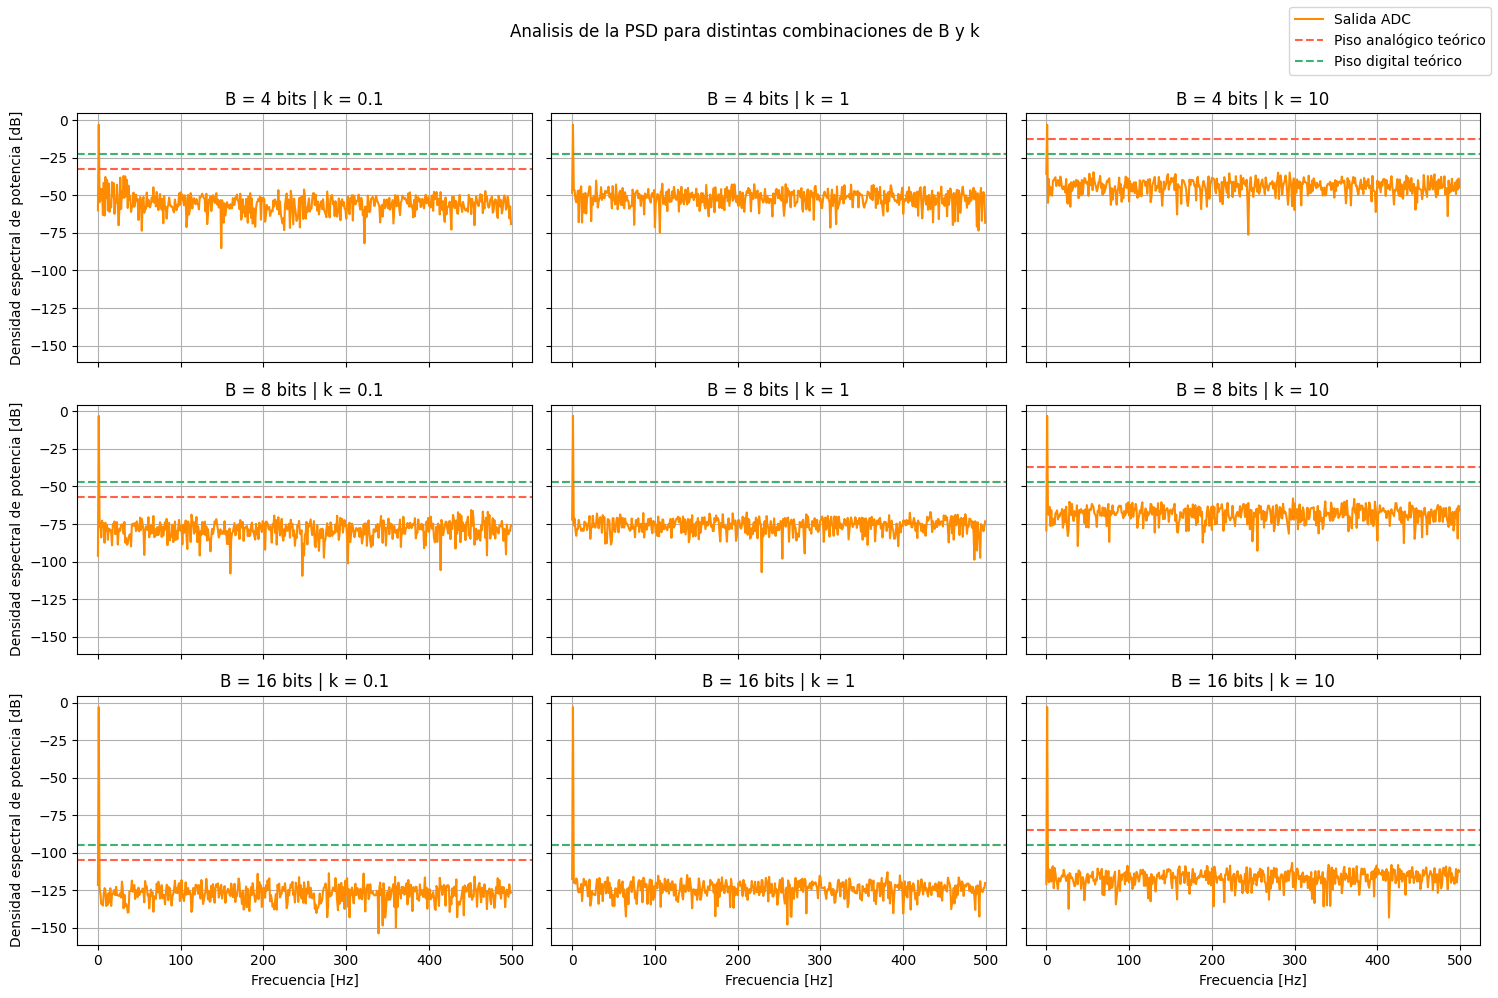

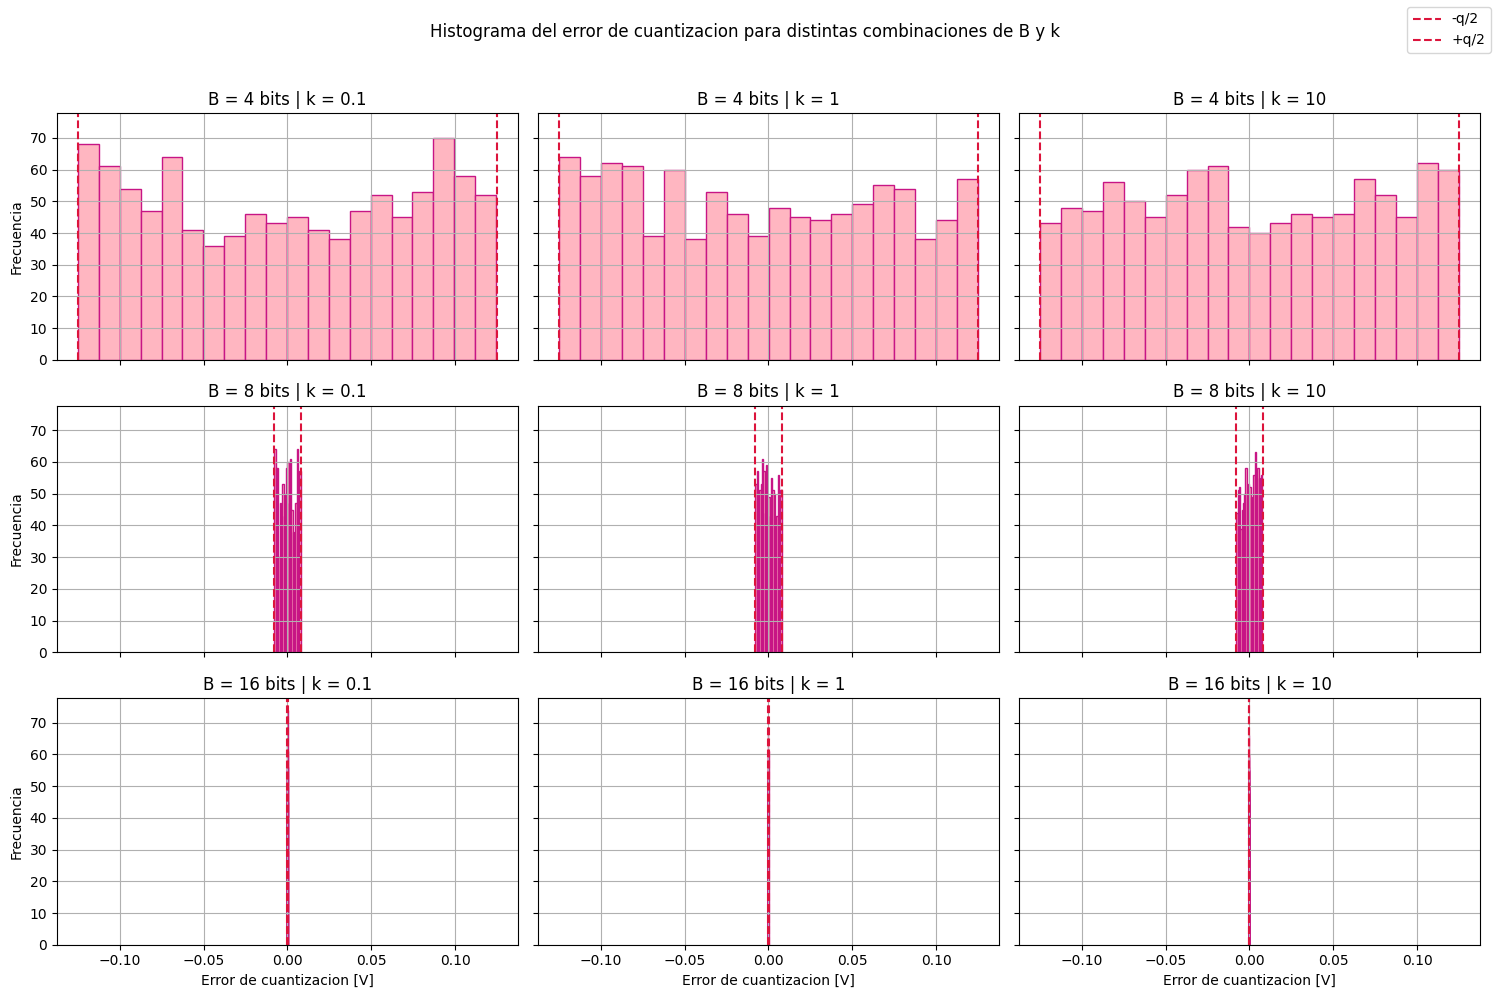

In [37]:
import numpy as np
import matplotlib.pyplot as plt
#%%
def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1/fs
    x = np.arange(nn)
    tt = x * ts
    xx = vmax * np.sin(2 * np.pi * ff * tt + ph) + dc
    return tt, xx
#%%parametros
fs = 1000
nn = 1000
vmax = np.sqrt(2)
dc = 0
ph = 0
VF = 2
ff = fs/nn

tt, xx = mi_funcion_sen(vmax, dc, ff, ph, nn, fs)

# vectores para cada valor
B_vals = [4, 8, 16]
kn_vals = [0.1, 1, 10]

# señal en el tiempo
fig_tiempo, axes_tiempo = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

#espectro
fig_fft, axes_fft = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

#histograma
fig_hist, axes_hist = plt.subplots(3, 3, figsize=(15, 10), sharex=True, sharey=True)

for i, B in enumerate(B_vals):
    for j, kn in enumerate(kn_vals):

#parametros
        q = (2 * VF) / (2**B)
        Pq = (q**2) / 12
        Pn = kn * Pq
#ruido de cuantizacion
        ruido_base = np.random.normal(0, 1, xx.shape)
        ruido = np.sqrt(Pn) * ruido_base
        sr = xx + ruido

        sr_clip = np.clip(sr, -VF, VF)
        sq = q * np.round(sr_clip / q)

#FFT
        DFT = np.fft.fft(sq)
        frecuencia = np.fft.fftfreq(nn, d=1/fs)

        mask = frecuencia >= 0
        frecuencia_pos = frecuencia[mask]
        DFT_positivo = DFT[mask]

        dens_pot_sq = (1 / nn**2) * (np.abs(DFT_positivo)**2)
        dens_pot_sq[dens_pot_sq == 0] = 1e-20
        dens_db_sq = 10 * np.log10(dens_pot_sq)

        piso_analog_db = 10 * np.log10(Pn)
        piso_digital_db = 10 * np.log10(Pq)
#error 
        error_q = sq - sr_clip
#grafico del tiempo
        ax_t = axes_tiempo[i, j]
        ax_t.plot(tt, sq, label='senal cuantizada', color='tab:blue')
        ax_t.plot(tt, sr, label='senal con ruido', color='plum')
        ax_t.plot(tt, xx, label='senoide ideal', linestyle=':', color='tab:green')
        ax_t.set_title(f'B = {B} bits | k = {kn}')
        ax_t.grid(True)

        if i == 2:
            ax_t.set_xlabel('Tiempo [s]')
        if j == 0:
            ax_t.set_ylabel('Amplitud [V]')

#grafico del espectro
        ax_f = axes_fft[i, j]
        ax_f.plot(frecuencia_pos, dens_db_sq, color='darkorange', label='Salida ADC')
        ax_f.axhline(piso_analog_db, color='tomato', linestyle='--', label='Piso analógico teórico')
        ax_f.axhline(piso_digital_db, color='mediumseagreen', linestyle='--', label='Piso digital teórico')
        ax_f.set_title(f'B = {B} bits | k = {kn}')
        ax_f.grid(True)

        if i == 2:
            ax_f.set_xlabel('Frecuencia [Hz]')
        if j == 0:
            ax_f.set_ylabel('Densidad espectral de potencia [dB]')
#histograma
        ax_h = axes_hist[i, j]
        ax_h.hist(error_q, bins=20, edgecolor='mediumvioletred', color='lightpink')
        ax_h.axvline(-q/2, color='crimson', linestyle='--', label='-q/2')
        ax_h.axvline(q/2, color='crimson', linestyle='--', label='+q/2')
        ax_h.set_title(f'B = {B} bits | k = {kn}')
        ax_h.grid(True)

        if i == 2:
            ax_h.set_xlabel('Error de cuantizacion [V]')
        if j == 0:
            ax_h.set_ylabel('Frecuencia')
#leyendas
handles_t, labels_t = axes_tiempo[0, 0].get_legend_handles_labels()
fig_tiempo.legend(handles_t, labels_t, loc='upper right')

handles_f, labels_f = axes_fft[0, 0].get_legend_handles_labels()
fig_fft.legend(handles_f, labels_f, loc='upper right')

handles_h, labels_h = axes_hist[0, 0].get_legend_handles_labels()
fig_hist.legend(handles_h, labels_h, loc='upper right')
#titulos
fig_tiempo.suptitle('Senal muestreada por el ADC para distintas combinaciones de B y k', y=0.98)
fig_fft.suptitle('Analisis de la PSD para distintas combinaciones de B y k', y=0.98)
fig_hist.suptitle('Histograma del error de cuantizacion para distintas combinaciones de B y k', y=0.98)

fig_tiempo.tight_layout(rect=[0, 0, 1, 0.96])
fig_fft.tight_layout(rect=[0, 0, 1, 0.96])
fig_hist.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

<br>
Se repitió el gráfico para k=1 y B=4 aunque ya se resolvió anteriormente solo para que quede plasmada la diferencia entre todos los valores.

## Conclusión 
A partir del análisis realizado, se concluye que la calidad de la señal digitalizada depende tanto de la resolución del ADC como del nivel de ruido analógico presente en la señal.
<br>
El aumento en la cantidad de bits reduce significativamente el error de cuantización, mejorando la señal y disminuyendo el piso de ruido digital. Sin embargo, cuando el ruido analógico es alto, la mejora en la resolución deja de ser fiable.
<br>
Por otro lado, cuando el ruido analógico es bajo, el error de cuantización se vuelve dominante, mostrando la importancia de utilizar una resolución adecuada.
<br>
Finalmente, los resultados obtenidos en el dominio del tiempo, en frecuencia y en el análisis del error validan el modelo teórico del ADC y muestran la interacción entre ruido analógico y ruido de cuantización.